Using device: cuda

📥 Downloading dataset via kagglehub …


100%|██████████| 235M/235M [00:01<00:00, 207MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/salmansajid05/oral-diseases/versions/3
🔀 Splitting dataset into train / val / test …
  train/Calculus: 932
  train/Caries: 1714
  train/Gingivitis: 1691
  train/Ulcers: 1828
  train/Tooth Discoloration: 1320
  train/Hypodontia: 900
    val/Calculus: 234
    val/Caries: 429
    val/Gingivitis: 423
    val/Ulcers: 458
    val/Tooth Discoloration: 330
    val/Hypodontia: 225
   test/Calculus: 130
   test/Caries: 239
   test/Gingivitis: 235
   test/Ulcers: 255
   test/Tooth Discoloration: 184
   test/Hypodontia: 126

Classes (6): ['Calculus', 'Caries', 'Gingivitis', 'Hypodontia', 'Tooth Discoloration', 'Ulcers']
Train: 8385 | Val: 2099 | Test: 1169


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 136MB/s]



PHASE 1: Training classifier head only (backbone frozen)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


  Epoch [1/5]  Train Loss: 1.3234  Train Acc: 0.5225  Val Loss: 1.0745  Val Acc: 0.6822
  Epoch [2/5]  Train Loss: 1.2184  Train Acc: 0.5802  Val Loss: 1.0682  Val Acc: 0.6603
  Epoch [3/5]  Train Loss: 1.1930  Train Acc: 0.6044  Val Loss: 1.0440  Val Acc: 0.6670
  Epoch [4/5]  Train Loss: 1.1569  Train Acc: 0.6159  Val Loss: 1.0375  Val Acc: 0.6927
  Epoch [5/5]  Train Loss: 1.1477  Train Acc: 0.6169  Val Loss: 1.0228  Val Acc: 0.7103

PHASE 2: Fine‑tuning (last 2 DenseBlocks unfrozen)
  Unfrozen 6,052,102 / 7,481,734 parameters (80.9%)
  Epoch [1/25]  Train Loss: 0.9371  Train Acc: 0.7449  Val Loss: 0.7859  Val Acc: 0.8294
    ✅ Saved new best model
  Epoch [2/25]  Train Loss: 0.7928  Train Acc: 0.8197  Val Loss: 0.7033  Val Acc: 0.8633
    ✅ Saved new best model
  Epoch [3/25]  Train Loss: 0.7236  Train Acc: 0.8592  Val Loss: 0.6713  Val Acc: 0.8895
    ✅ Saved new best model
  Epoch [4/25]  Train Loss: 0.6779  Train Acc: 0.8852  Val Loss: 0.6241  Val Acc: 0.8990
    ✅ Saved new bes

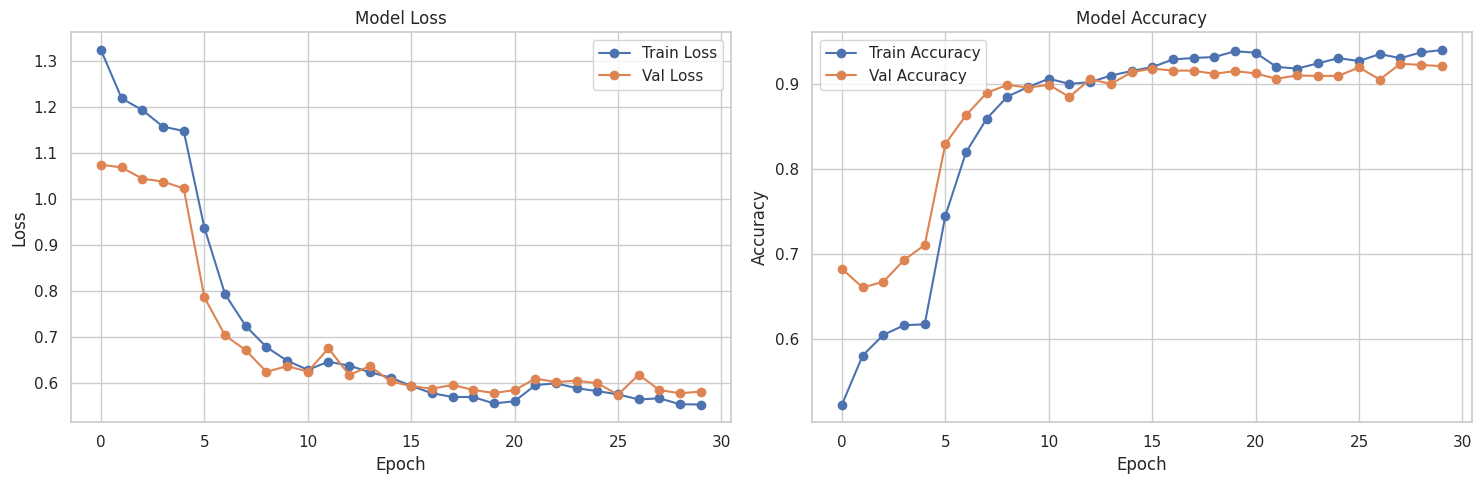

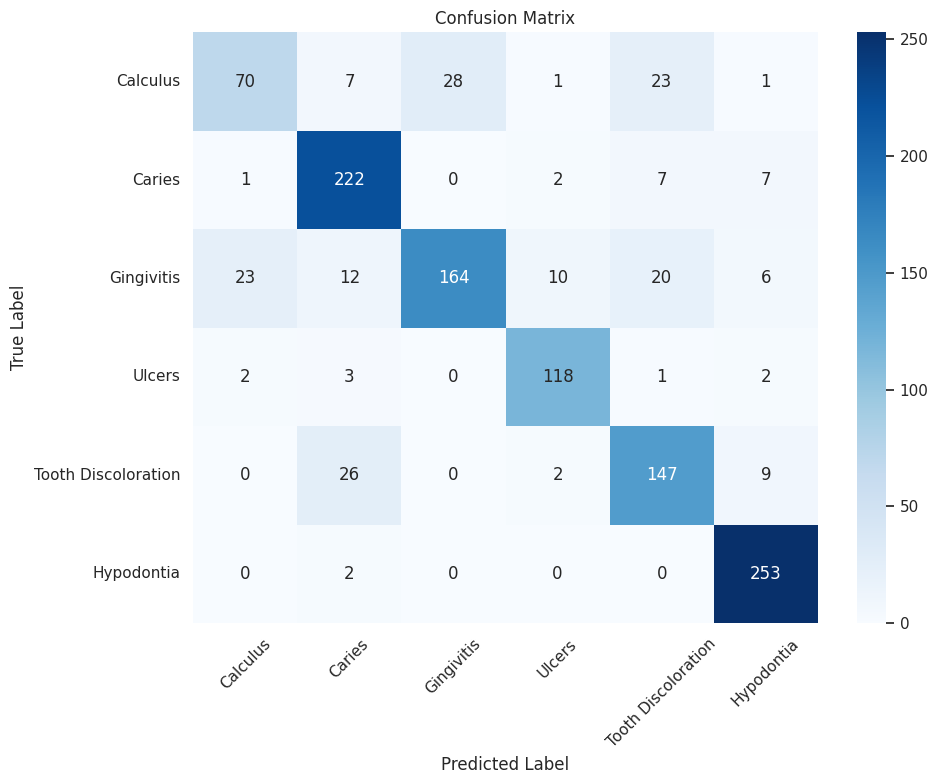

In [1]:
"""
Improved DenseNet121 Training Script for Oral Disease Classification
====================================================================
Improvements over the original notebook:
  1. 2-phase training: frozen backbone (5 epochs) → unfreeze last 2 DenseBlocks (25 epochs)
  2. Differential learning rates (backbone vs classifier head)
  3. CosineAnnealingWarmRestarts scheduler
  4. Enhanced data augmentation (GaussianBlur, RandomPerspective, RandomErasing)
  5. WeightedRandomSampler for class imbalance
  6. More epochs (30 total) with early stopping (patience=7)

Usage (Kaggle / Colab with GPU):
  1. Upload this file to your Kaggle notebook or Colab.
  2. Run:  !python train_improved.py
  3. Download the resulting 'densenet_oral_model_improved.pth' and place it
     alongside app.py to serve the improved model.

The dataset is automatically downloaded via kagglehub.
"""

import os
import shutil
import random
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.models import densenet121
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ────────────────────────────────────────────────────────────
# Reproducibility
# ────────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ────────────────────────────────────────────────────────────
# Configuration
# ────────────────────────────────────────────────────────────
BATCH_SIZE = 32
PHASE1_EPOCHS = 5       # Frozen backbone warm‑up
PHASE2_EPOCHS = 25      # Fine‑tune with unfrozen last 2 DenseBlocks
PATIENCE = 7            # Early stopping patience (applies in Phase 2)
CLASSIFIER_LR = 1e-3
BACKBONE_LR = 1e-4
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.1
NUM_WORKERS = 4
MODEL_SAVE_PATH = "densenet_oral_model_improved.pth"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# ────────────────────────────────────────────────────────────
# 1. Dataset Download & Splitting
# ────────────────────────────────────────────────────────────
print("\n📥 Downloading dataset via kagglehub …")
import kagglehub

dataset_root = kagglehub.dataset_download("salmansajid05/oral-diseases")
print(f"Dataset path: {dataset_root}")

# Map class names to source directories (must match exact Kaggle dataset structure)
original_dirs = {
    "Calculus":             os.path.join(dataset_root, "Calculus", "Calculus"),
    "Caries":              os.path.join(dataset_root, "Data caries", "Data caries", "caries augmented data set", "preview"),
    "Gingivitis":          os.path.join(dataset_root, "Gingivitis", "Gingivitis"),
    "Ulcers":              os.path.join(dataset_root, "Mouth Ulcer", "Mouth Ulcer", "Mouth_Ulcer_augmented_DataSet", "preview"),
    "Tooth Discoloration": os.path.join(dataset_root, "Tooth Discoloration", "Tooth Discoloration ", "Tooth_discoloration_augmented_dataser", "preview"),
    "Hypodontia":          os.path.join(dataset_root, "hypodontia", "hypodontia"),
}

BASE_DIR = "./dataset_improved"
SPLITS = ["train", "val", "test"]
CLASSES = list(original_dirs.keys())

# Create directory structure
for split in SPLITS:
    for cls in CLASSES:
        os.makedirs(os.path.join(BASE_DIR, split, cls), exist_ok=True)

# Split & copy images (70/20/10)
print("🔀 Splitting dataset into train / val / test …")
for class_name, src_dir in original_dirs.items():
    # Use os.walk to find images in nested directories (matches notebook approach)
    image_paths = [
        os.path.join(root, f)
        for root, _, files in os.walk(src_dir)
        for f in files
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]
    if not image_paths:
        print(f"  ⚠️  No images found for '{class_name}' in {src_dir}")
        continue
    train_paths, test_paths = train_test_split(image_paths, test_size=0.1, random_state=SEED)
    train_paths, val_paths = train_test_split(train_paths, test_size=0.2, random_state=SEED)

    for split_name, paths in [("train", train_paths), ("val", val_paths), ("test", test_paths)]:
        for img_path in paths:
            dst = os.path.join(BASE_DIR, split_name, class_name, os.path.basename(img_path))
            if not os.path.exists(dst):
                shutil.copy2(img_path, dst)

for split in SPLITS:
    for cls in CLASSES:
        count = len(os.listdir(os.path.join(BASE_DIR, split, cls)))
        print(f"  {split:>5s}/{cls}: {count}")

# ────────────────────────────────────────────────────────────
# 2. Transforms (enhanced augmentation)
# ────────────────────────────────────────────────────────────
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.15)),
])

val_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# ────────────────────────────────────────────────────────────
# 3. Datasets & DataLoaders
# ────────────────────────────────────────────────────────────
train_dir = os.path.join(BASE_DIR, "train")
val_dir   = os.path.join(BASE_DIR, "val")
test_dir  = os.path.join(BASE_DIR, "test")

train_dataset = ImageFolder(train_dir, transform=train_transforms)
val_dataset   = ImageFolder(val_dir,   transform=val_transforms)
test_dataset  = ImageFolder(test_dir,  transform=val_transforms)

# Weighted sampler for class imbalance
class_counts = Counter(train_dataset.targets)
total = sum(class_counts.values())
class_weights = {cls: total / count for cls, count in class_counts.items()}
sample_weights = [class_weights[t] for t in train_dataset.targets]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

num_classes = len(train_dataset.classes)
print(f"\nClasses ({num_classes}): {train_dataset.classes}")
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

# ────────────────────────────────────────────────────────────
# 4. Model Definition
# ────────────────────────────────────────────────────────────
class CustomDenseNet(nn.Module):
    def __init__(self, num_classes: int) -> None:
        super().__init__()
        self.model = densenet121(weights="IMAGENET1K_V1")

        # Freeze entire backbone initially
        for param in self.model.features.parameters():
            param.requires_grad = False

        # Replace classifier head
        in_features = self.model.classifier.in_features
        self.model.classifier = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(in_features, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.2),
            nn.Linear(512, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.model(x)

    def unfreeze_last_n_denseblocks(self, n: int = 2) -> None:
        """Unfreeze the last `n` DenseBlocks + transition layers for fine‑tuning."""
        # DenseNet121 features: denseblock1, transition1, denseblock2, transition2,
        #                       denseblock3, transition3, denseblock4, norm5
        blocks = [name for name, _ in self.model.features.named_children()]
        # Unfreeze from the tail
        unfreeze_from = blocks[-n * 2:]  # each dense block + its transition
        for name, module in self.model.features.named_children():
            if name in unfreeze_from:
                for param in module.parameters():
                    param.requires_grad = True
        unfrozen = sum(p.numel() for p in self.model.parameters() if p.requires_grad)
        total    = sum(p.numel() for p in self.model.parameters())
        print(f"  Unfrozen {unfrozen:,} / {total:,} parameters "
              f"({unfrozen / total * 100:.1f}%)")


model = CustomDenseNet(num_classes).to(DEVICE)

# ────────────────────────────────────────────────────────────
# 5. Training Helpers
# ────────────────────────────────────────────────────────────
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)


def train_one_epoch(model, loader, optimizer, scheduler, epoch_num):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)

    scheduler.step(epoch_num)
    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        loss = criterion(outputs, labels)
        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total


# ────────────────────────────────────────────────────────────
# 6. Phase 1 — Frozen Backbone Warm‑Up
# ────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("PHASE 1: Training classifier head only (backbone frozen)")
print("=" * 60)

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=CLASSIFIER_LR, weight_decay=WEIGHT_DECAY,
)
scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=1)

best_val_loss = float("inf")

history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': []
}

for epoch in range(PHASE1_EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, scheduler, epoch)
    val_loss, val_acc = evaluate(model, val_loader)
    print(f"  Epoch [{epoch + 1}/{PHASE1_EPOCHS}]  "
          f"Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.4f}  "
          f"Val Loss: {val_loss:.4f}  Val Acc: {val_acc:.4f}")
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), MODEL_SAVE_PATH)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

# ────────────────────────────────────────────────────────────
# 7. Phase 2 — Fine‑Tune with Unfrozen DenseBlocks
# ────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("PHASE 2: Fine‑tuning (last 2 DenseBlocks unfrozen)")
print("=" * 60)

model.unfreeze_last_n_denseblocks(n=2)

# Differential learning rates
param_groups = [
    {"params": [p for n, p in model.model.features.named_parameters() if p.requires_grad],
     "lr": BACKBONE_LR},
    {"params": model.model.classifier.parameters(),
     "lr": CLASSIFIER_LR},
]
optimizer = optim.AdamW(param_groups, weight_decay=WEIGHT_DECAY)
scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=2)

epochs_no_improve = 0

for epoch in range(PHASE2_EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, scheduler, epoch)
    val_loss, val_acc = evaluate(model, val_loader)
    print(f"  Epoch [{epoch + 1}/{PHASE2_EPOCHS}]  "
          f"Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.4f}  "
          f"Val Loss: {val_loss:.4f}  Val Acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print("    ✅ Saved new best model")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"    ⏹ Early stopping after {epoch + 1} epochs (no improvement for {PATIENCE}).")
            break

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

# ────────────────────────────────────────────────────────────
# 8. Test‑Time Evaluation with TTA
# ────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("EVALUATION on Test Set (with TTA)")
print("=" * 60)

# Reload best weights
model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=DEVICE))
model.eval()

tta_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

NUM_TTA = 5
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        # Standard prediction
        outputs = torch.softmax(model(images), dim=1)

        # TTA: denormalize → re‑augment → average
        mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1).to(DEVICE)
        std  = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1).to(DEVICE)

        for _ in range(NUM_TTA):
            denorm = images * std + mean
            augmented = torch.stack([
                tta_transforms(transforms.ToPILImage()(img.cpu()))
                for img in denorm
            ]).to(DEVICE)
            outputs += torch.softmax(model(augmented), dim=1)

        avg_outputs = outputs / (NUM_TTA + 1)
        preds = avg_outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
print(f"\n🎯 Test Accuracy (with TTA): {test_accuracy * 100:.2f}%")
print(f"\nClassification Report:\n")
print(classification_report(all_labels, all_preds, target_names=CLASSES))
print(f"Confusion Matrix:\n{confusion_matrix(all_labels, all_preds)}")
print(f"\n📦 Model saved to: {MODEL_SAVE_PATH}")
print("Done! Copy the .pth file alongside app.py and update MODEL_PATH to use the improved model.")

# ────────────────────────────────────────────────────────────
# 9. Visualizations
# ────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(history['train_loss'], label='Train Loss', marker='o')
ax1.plot(history['val_loss'], label='Val Loss', marker='o')
ax1.set_title('Model Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(history['train_acc'], label='Train Accuracy', marker='o')
ax2.plot(history['val_acc'], label='Val Accuracy', marker='o')
ax2.set_title('Model Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
plt.tight_layout()
plt.show()

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
